<div align="center">
<b>In the Name of God</b>
</div>

<div>
<span style="float:left;"><b>Project Title: Student Dropout Prediction</b></span>
<span style="float:right;"><b>Donya Fallah</b></span>

</div>

<br>

## 1. Initial Data Exploration

In this stage, the dataset of the **Student_Dropout_Prediction** project is loaded, and an initial examination of its structure is performed.  
The purpose of this step is to become familiar with the data before applying any preprocessing or modeling techniques.

First, the data file is read using the **pandas** library.

- The number of rows and columns is checked to determine the overall dimensions of the dataset.
- The first few rows of the data are displayed to observe the types and values of the features.
- General information about each column (such as data type and number of non-null values) is examined to identify potential issues like missing data.
- Descriptive statistics of the features (such as mean, minimum, maximum, and potential outliers) are calculated to better understand the data distribution.

This step is essential to avoid incorrect decisions in later stages, since the choice of preprocessing methods and models directly depends on the structure and characteristics of the data.


In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")

print("Rows, cols:", df.shape)

display(df.head())

display(df.info())

display(df.describe(include="all").T)

Rows, cols: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,6.88698,5.298964,1.0,1.0,8.0,12.0,18.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,9.899186,4.331792,1.0,6.0,10.0,13.0,17.0
Daytime/evening attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,2.53142,3.963707,1.0,1.0,1.0,1.0,17.0
Nacionality,4424.0,NaN,NaN,NaN,1.254521,1.748447,1.0,1.0,1.0,1.0,21.0
Mother's qualification,4424.0,NaN,NaN,NaN,12.322107,9.026251,1.0,2.0,13.0,22.0,29.0
Father's qualification,4424.0,NaN,NaN,NaN,16.455244,11.0448,1.0,3.0,14.0,27.0,34.0
Mother's occupation,4424.0,NaN,NaN,NaN,7.317812,3.997828,1.0,5.0,6.0,10.0,32.0


## 2. Target and Missing Data Exploration

In this stage, the target variable and the quality of the data are examined:

### Missing Values
Using `df.isna().sum()`, the number of missing values in each column is identified.  
This helps decide whether to fill in missing data or remove it before modeling.

In [87]:
df.isna().sum().sort_values(ascending=False)

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

### Class Distribution
Using `value_counts()`, the number of samples in each class of the target is determined.  
With `value_counts(normalize=True)`, the percentage of each class is checked.  
This step is essential to detect potential **class imbalance** issues.

In [88]:
print(df['Target'].value_counts())
print("--------------")
print(df['Target'].value_counts(normalize=True))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
--------------
Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64


### Mapping Target to Numeric Values
Machine learning models work only with numeric data. Therefore, the target classes are converted to numbers:

- `"Dropout"` → 0  
- `"Enrolled"` → 1  
- `"Graduate"` → 2  

In [89]:
target_mapping = {"Dropout":0 ,  "Graduate":2 , "Enrolled":1}



### Separating Features and Target (X and y)
After conversion, the `Target` column is separated from the dataset so that **features (X)** and **target (y)** are ready for modeling.

In [90]:
X = df.drop("Target", axis=1)
y = df["Target"].map(target_mapping)

## 3. Feature Preprocessing

Columns are split into two types and processed accordingly. This is important for models that:

- Are sensitive to feature scales (KNN, Logistic Regression, SVM)  
- Cannot handle categorical data directly  

**Numerical Columns (`numerical_cols`)**  
- Real-valued features like grades or economic indicators  
- Normalized with **StandardScaler** (zero mean, unit variance)  

**Categorical Columns (`categorical_cols`)**  
- Represent categories (marital status, course, parents' qualifications)  
- Converted to binary vectors using **One-Hot Encoding**  

**OneHotEncoder Parameters:**  
- `drop='first'` → Avoids dummy variable trap in linear models  
- `handle_unknown='ignore'` → Ignores unseen categories in test data  

**Summary:**  
Using **ColumnTransformer**, preprocessing is applied automatically per column type, making pipelines standard, robust, and preventing common mistakes like scaling categorical data or multicollinearity.


In [91]:
categorical_cols = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

numerical_cols = [
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

target_col = 'Target'

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)
preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Curricular units 1st sem (credited)',
                                  'Curricular units 1st sem (enrolled)',
                                  'Curricular units 1st sem (evaluations)',
                                  'Curricular units 1st sem (approved)',
                                  'Curricular units 1st sem (grade)',
                                  'Curricular units 1st sem (without '
                                  'evaluations)',
                                  'Curricular units 2nd sem (credited)',
                                  'Curricular units 2nd sem (enrolled)',
                                  'Curricul...
                                  'Curricular units 2nd sem (without '
                                  'evaluations)',
                                  'Unemployment rate', 'Inflation rate',
                                  'GDP']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Marital status', 'Application mode',
                                  'Application order', 'Course',
                                  'Daytime/evening attendance',
                                  'Previous qualification', 'Nacionality',
                                  "Mother's qualification",
                                  "Father's qualification",
                                  "Mother's occupation",
                                  "Father's occupation"])])

## 4. Train-Test Split

The dataset is split into two parts:

- **Training set (`X_train, y_train`)**: Used to train the model.  
- **Test set (`X_test, y_test`)**: Used to evaluate the model on unseen data.

In [92]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)


## 5. Train models

## First Model: Train Random Forest Model

We use **Random Forest** to predict student outcomes because:

- Handles numeric and categorical data without special preprocessing.  
- Robust to outliers and noisy data.  
- Supports multi-class prediction and provides feature importance.

The model learns the relationship between features and target using the training set and is ready for evaluation on the test set.


In [93]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train , y_train) 

RandomForestClassifier(random_state=42)

**Feature Importance**

After training the Random Forest, we can identify which features most influence student outcome predictions.

- `model.feature_importances_` shows each feature's importance.  
- A **bar plot** visualizes these importances, helping to see which variables the model relies on most.

This step is useful for **understanding model behavior** and **focusing on influential features**.


In [94]:
#Important Features
importances = model.feature_importances_
features_names = X_train.columns
feat_imp_df = pd.DataFrame({"Fetures": features_names , "importance": importances}) 
feat_imp_df.sort_values(by="importance" , ascending=False)

,Fetures,importance
28,Curricular units 2nd sem (approved),0.146862
29,Curricular units 2nd sem (grade),0.103916
22,Curricular units 1st sem (approved),0.091930
23,Curricular units 1st sem (grade),0.072925
17,Age at enrollment,0.046114
27,Curricular units 2nd sem (evaluations),0.043693
14,Tuition fees up to date,0.038270
3,Course,0.037696
21,Curricular units 1st sem (evaluations),0.036264
10,Father's occupation,0.034062


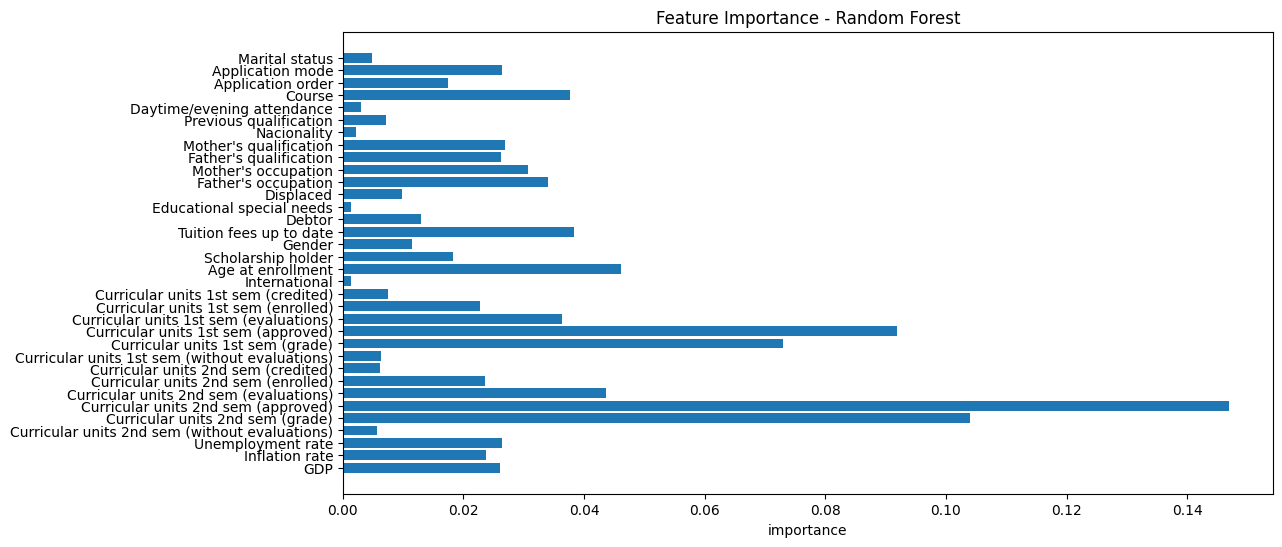

In [95]:
plt.figure(figsize=(12,6))
plt.barh(feat_imp_df["Fetures"], feat_imp_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("importance")
plt.title("Feature Importance - Random Forest")
plt.show()

##  Random Forest Model Evaluation

After training the Random Forest, we evaluate its performance on the test set.


In [96]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)
print("Accuracy score:" , accuracy_score(y_test,y_pred))
print("-----------------------")
print("Confusion Matrix:")
print(confusion_matrix(y_test,y_pred))
print("-----------------------")
print("Classification report:")
print( classification_report(y_test,y_pred))

Accuracy score: 0.7785310734463277
-----------------------
Confusion Matrix:
[[213  27  44]
 [ 37  60  62]
 [ 10  16 416]]
-----------------------
Classification report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       284
           1       0.58      0.38      0.46       159
           2       0.80      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.77      0.78      0.76       885



## Second Model: Training K-Nearest Neighbors (KNN)

In this step, a basic K-Nearest Neighbors model is trained as a baseline.

- This model uses default hyperparameters and serves as a reference point for later comparisons.
- Data preprocessing (scaling and one-hot encoding) is applied through a Pipeline to ensure proper distance calculations.


In [97]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  
    ('classifier', KNeighborsClassifier())
])
knn_pipeline.fit(X_train, y_train)
y_pred_simple_knn = knn_pipeline.predict(X_test)

## KNN Hyperparameter Tuning using GridSearchCV
In this step, GridSearchCV is used to tune the KNN model.
- Key hyperparameters such as the number of neighbors (n_neighbors) and the weighting method (weights) are explored.
- A 5-fold cross-validation is applied, and F1-macro is used as the evaluation metric since the problem is multiclass.

In [98]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_neighbors': [3,5,7,9,11],
    'classifier__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro'
)

grid_knn.fit(X_train, y_train)

print("Best params:", grid_knn.best_params_)

best_knn = grid_knn.best_estimator_
y_pred_tuned_knn = best_knn.predict(X_test)


Best params: {'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}


## baseline KNN vs. tuned KNN:
In this step, the performance of the baseline KNN and the tuned KNN models is compared.
- For both models, Accuracy and F1-macro scores are reported, along with their Confusion Matrices.
- This comparison highlights the impact of hyperparameter tuning on model performance.

In [99]:
from sklearn.metrics import accuracy_score, f1_score

print("Simple KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_simple_knn))
print("F1 macro:", f1_score(y_test, y_pred_simple_knn, average='macro'))

print("\nTuned KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_knn))
print("F1 macro:", f1_score(y_test, y_pred_tuned_knn, average='macro'))

print("\nSimple KNN Confusion Matrix")
print(confusion_matrix(y_test, y_pred_simple_knn))

print("\nTuned KNN Confusion Matrix")
print(confusion_matrix(y_test, y_pred_tuned_knn))


Simple KNN
Accuracy: 0.6757062146892655
F1 macro: 0.5780547150148162

Tuned KNN
Accuracy: 0.6926553672316385
F1 macro: 0.5852408496874707

Simple KNN Confusion Matrix
[[173  43  68]
 [ 41  38  80]
 [ 31  24 387]]

Tuned KNN Confusion Matrix
[[172  26  86]
 [ 39  34  86]
 [ 23  12 407]]
